# Extraction EDA

Run `uv run -m uni_rag_agent extract run` after inventory has populated `data/uni_rag.sqlite`, then use this notebook to inspect extraction yield, failures, chunk counts, source types, source-location coverage, and quick diagnostic plots.

Safety boundary: this notebook is read-only. It reads generated app data only, opens SQLite in read-only mode, enables `PRAGMA query_only=ON`, and must not mutate SQLite, `Courses`, or any course file. Plots use pandas and matplotlib over already-generated app tables.

In [11]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import Markdown, display
except ImportError:  # Allows helper cells to run outside Jupyter smoke checks.
    Markdown = None
    display = print


def display_md(text: str) -> None:
    if Markdown is not None:
        display(Markdown(text))
    else:
        print(text)


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "context").is_dir():
            return candidate
    raise RuntimeError("Could not find repo root. Start Jupyter from this project or notebooks/.")


def show_barh(series: pd.Series, title: str, xlabel: str, color: str = "#4C78A8", max_rows: int = 15) -> None:
    data = series.dropna()
    data = data[data > 0].sort_values(ascending=True).tail(max_rows)
    if data.empty:
        display_md("_No rows to plot._")
        return
    height = max(3.0, 0.35 * len(data) + 1.2)
    ax = data.plot(kind="barh", figsize=(9, height), color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.bar_label(ax.containers[0], padding=3)
    ax.figure.subplots_adjust(left=0.35, right=0.92, top=0.88, bottom=0.15)
    plt.show()


pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 160)
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

repo_root = find_repo_root(Path.cwd().resolve())
sqlite_path = repo_root / "data" / "uni_rag.sqlite"
if not sqlite_path.is_file():
    raise FileNotFoundError(
        f"Extraction database not found at {sqlite_path}. Run "
        "`uv run -m uni_rag_agent storage init`, then "
        "`uv run -m uni_rag_agent inventory run`, then "
        "`uv run -m uni_rag_agent extract run`."
    )
sqlite_uri = sqlite_path.resolve().as_uri() + "?mode=ro"

connection = sqlite3.connect(sqlite_uri, uri=True, timeout=5)
_ = connection.execute("PRAGMA query_only=ON")
display_md(f"**SQLite database:** `{sqlite_path}`")

**SQLite database:** `D:\Projects\Uni RAG Agent\data\uni_rag.sqlite`

## Plotting Helpers

The plots below are quick diagnostics over generated SQLite tables. They use pandas plus matplotlib and should remain lightweight enough to rerun after each extraction pass.

In [12]:
latest_runs = pd.read_sql_query(
    """
    SELECT id, started_at, finished_at, status, config_json,
           files_seen, files_indexed, files_metadata_only, files_failed, error
    FROM extraction_runs
    ORDER BY id DESC
    LIMIT 20
    """,
    connection,
)
latest_runs

,id,started_at,finished_at,status,config_json,files_seen,files_indexed,files_metadata_only,files_failed,error
0,2,2026-06-27T16:51:54.551331+00:00,2026-06-27T16:58:46.656367+00:00,completed,"{""category"": null, ""courses_root"": ""D:\\Projects\\Uni RAG Agent\\Courses"", ""data_dir"": ""D:\\Projects\\Uni RAG Agent\\data"", ""handled_cat...",1482,1337,0,145,None
1,1,2026-06-25T21:22:38.461169+00:00,2026-06-25T21:42:58.532961+00:00,completed,"{""classification_categories"": [""archive_metadata_only"", ""binary_metadata_only"", ""code"", ""data_schema"", ""document"", ""image_metadata_only""...",33912,0,27233,0,None


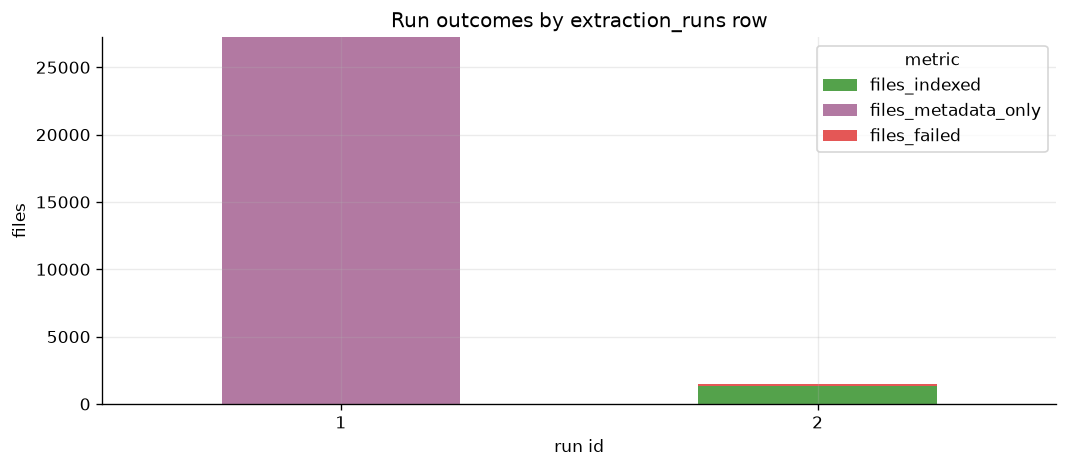

In [13]:
run_metrics = latest_runs.sort_values("id").set_index("id")[
    ["files_indexed", "files_metadata_only", "files_failed"]
]
if run_metrics.empty:
    display_md("_No extraction run rows to plot._")
else:
    ax = run_metrics.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 4),
        color=["#54A24B", "#B279A2", "#E45756"],
    )
    ax.set_title("Run outcomes by extraction_runs row")
    ax.set_xlabel("run id")
    ax.set_ylabel("files")
    ax.legend(title="metric")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [14]:
extraction_docs = pd.read_sql_query(
    """
    SELECT extracted_documents.id AS extracted_document_id,
           files.id AS file_id,
           courses.name AS course_name,
           files.relative_path,
           files.extension,
           files.category,
           files.index_status,
           files.reason_not_indexed,
           extracted_documents.extractor_name,
           extracted_documents.status AS extraction_status,
           extracted_documents.text_length,
           extracted_documents.chunk_count,
           extracted_documents.error,
           COALESCE(extracted_documents.error, files.reason_not_indexed) AS failure_reason,
           extracted_documents.extracted_at
    FROM extracted_documents
    JOIN files ON files.id = extracted_documents.file_id
    LEFT JOIN courses ON courses.id = files.course_id
    ORDER BY extracted_documents.extracted_at DESC, files.relative_path
    """,
    connection,
)
extraction_docs.head(25)

,extracted_document_id,file_id,course_name,relative_path,extension,category,index_status,reason_not_indexed,extractor_name,extraction_status,text_length,chunk_count,error,failure_reason,extracted_at
0,1482,33912,Uni Textbooks,Uni Textbooks\Starting_Out_with_Programming_Logic_and_Design_(5th_Edition)_by_Tony_Gaddis.pdf,.pdf,document,indexed,NaN,pdf-pymupdf,indexed,1302039,971,NaN,NaN,2026-06-27T16:58:46.526673+00:00
1,1481,33911,Uni Textbooks,Uni Textbooks\rosen_discrete_mathematics_and_its_applications_7th_edition.pdf,.pdf,document,indexed,NaN,pdf-pymupdf,indexed,3569454,1166,NaN,NaN,2026-06-27T16:58:39.106476+00:00
2,1480,33910,Uni Textbooks,"Uni Textbooks\Passages Level 2 Students Book (Jack C. Richards, Chuck Sandy) (z-lib.org).pdf",.pdf,document,indexed,NaN,pdf-pymupdf,indexed,367306,152,NaN,NaN,2026-06-27T16:58:25.484288+00:00
3,1479,33909,Uni Textbooks,Uni Textbooks\Foundations of CS 4th Edition- Behrouz Forouzan.pdf,.pdf,document,indexed,NaN,pdf-pymupdf,indexed,1254629,681,NaN,NaN,2026-06-27T16:58:10.277168+00:00
4,1478,33908,Uni Textbooks,Uni Textbooks\037-Elementary-Linear-Algebra-Applications-Version-Howard-Anton-Chris-Rorres-Edisi-1-2013.pdf,.pdf,document,indexed,NaN,pdf-pymupdf,indexed,1835209,793,NaN,NaN,2026-06-27T16:57:57.586382+00:00
5,1477,33907,Techincal Writing,Techincal Writing\Worksheets\worksheet4.docx,.docx,document,indexed,NaN,docx-python-docx,indexed,1360,1,NaN,NaN,2026-06-27T16:57:51.755333+00:00
6,1476,33906,Techincal Writing,Techincal Writing\Worksheets\Worksheet2 solution.docx,.docx,document,indexed,NaN,docx-python-docx,indexed,2507,1,NaN,NaN,2026-06-27T16:57:51.682099+00:00
7,1475,33905,Techincal Writing,Techincal Writing\Worksheets\Worksheet 6.docx,.docx,document,indexed,NaN,docx-python-docx,indexed,1304,1,NaN,NaN,2026-06-27T16:57:51.616725+00:00
8,1474,33904,Techincal Writing,Techincal Writing\Worksheets\Worksheet 5.docx,.docx,document,indexed,NaN,docx-python-docx,indexed,1263,1,NaN,NaN,2026-06-27T16:57:51.567864+00:00
9,1473,33903,Techincal Writing,Techincal Writing\Worksheets\Worksheet 3.docx,.docx,document,indexed,NaN,docx-python-docx,indexed,3665,1,NaN,NaN,2026-06-27T16:57:51.519500+00:00


In [15]:
coverage_by_category = pd.read_sql_query(
    """
    SELECT files.category,
           files.extension,
           files.index_status,
           COUNT(*) AS file_count
    FROM files
    WHERE files.category IN ('document', 'slides', 'notebook', 'code', 'transcript')
    GROUP BY files.category, files.extension, files.index_status
    ORDER BY files.category, files.extension, files.index_status
    """,
    connection,
)
coverage_by_category

,category,extension,index_status,file_count
0,code,.cpp,indexed,21
1,code,.h,indexed,4
2,code,.m,indexed,5
3,code,.py,failed,13
4,code,.py,indexed,120
5,code,.r,indexed,45
6,document,.doc,failed,15
7,document,.docx,failed,1
8,document,.docx,indexed,112
9,document,.md,indexed,10


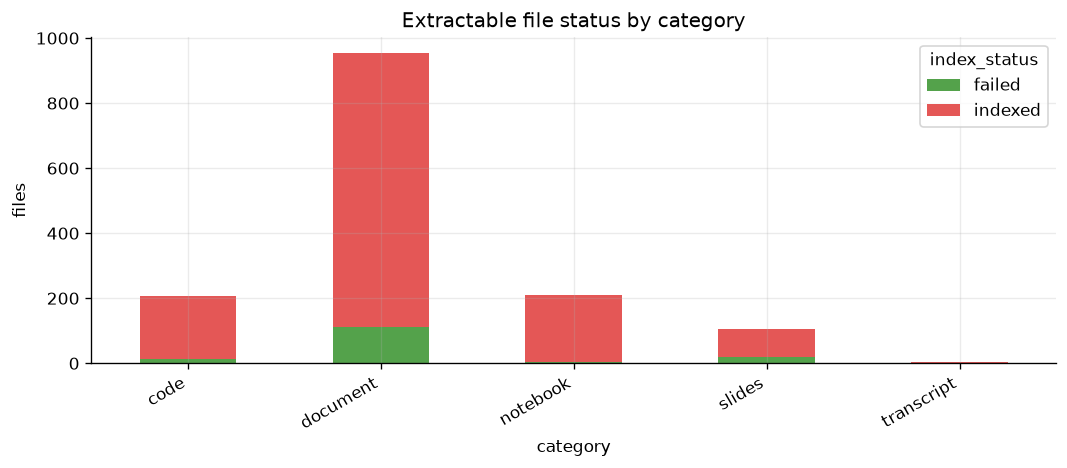

In [16]:
coverage_pivot = coverage_by_category.pivot_table(
    index="category",
    columns="index_status",
    values="file_count",
    aggfunc="sum",
    fill_value=0,
)
if coverage_pivot.empty:
    display_md("_No category coverage rows to plot._")
else:
    ax = coverage_pivot.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 4),
        color=["#54A24B", "#E45756", "#F58518", "#72B7B2", "#B279A2"],
    )
    ax.set_title("Extractable file status by category")
    ax.set_xlabel("category")
    ax.set_ylabel("files")
    ax.legend(title="index_status")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [17]:
chunks = pd.read_sql_query(
    """
    SELECT chunks.id AS chunk_id,
           files.id AS file_id,
           courses.name AS course_name,
           files.relative_path,
           files.extension,
           chunks.source_type,
           chunks.location_type,
           chunks.location_value,
           chunks.token_count,
           LENGTH(chunks.text) AS text_chars
    FROM chunks
    JOIN files ON files.id = chunks.file_id
    LEFT JOIN courses ON courses.id = files.course_id
    ORDER BY files.relative_path, chunks.chunk_index
    """,
    connection,
)
chunks.head(25)

,chunk_id,file_id,course_name,relative_path,extension,source_type,location_type,location_value,token_count,text_chars
0,1,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,1,13,95
1,2,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,2,4,27
2,3,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,3,40,254
3,4,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,4,43,271
4,5,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,5,65,396
5,6,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,6,36,220
6,7,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,7,62,390
7,8,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,8,68,366
8,9,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,9,59,279
9,10,4,Algorithms Design and Analysis,Algorithms Design and Analysis\1-Graphs\2 graphs-defs-long.pdf,.pdf,document,page,10,84,409


In [18]:
chunk_source_summary = (
    chunks.groupby(["source_type", "location_type"], dropna=False)
    .agg(chunk_count=("chunk_id", "count"), median_tokens=("token_count", "median"), max_tokens=("token_count", "max"))
    .reset_index()
    .sort_values(["source_type", "location_type"])
)
chunk_source_summary

,source_type,location_type,chunk_count,median_tokens,max_tokens
0,code,class,137,45.0,839
1,code,function,594,38.0,991
2,code,module,287,26.0,823
3,code,subchunk,22,1000.0,1000
4,document,docx_section,137,413.0,1000
5,document,markdown_section,103,46.0,279
6,document,page,17436,123.0,998
7,document,subchunk,224,986.5,1000
8,document,text_section,397,1.0,1000
9,notebook,notebook_cell,3802,23.0,673


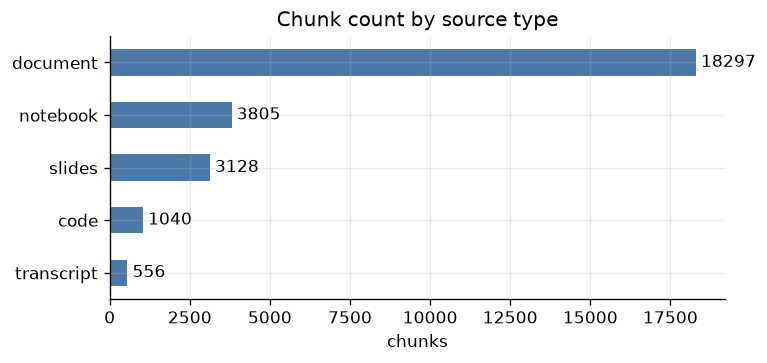

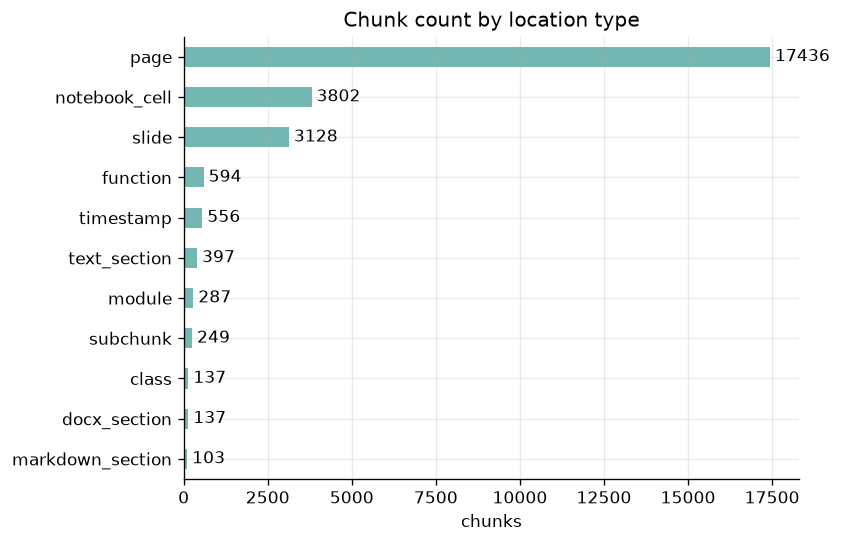

In [19]:
show_barh(
    chunks["source_type"].fillna("(missing source_type)").value_counts(),
    "Chunk count by source type",
    "chunks",
    color="#4C78A8",
)
show_barh(
    chunks["location_type"].fillna("(missing location_type)").value_counts(),
    "Chunk count by location type",
    "chunks",
    color="#72B7B2",
)

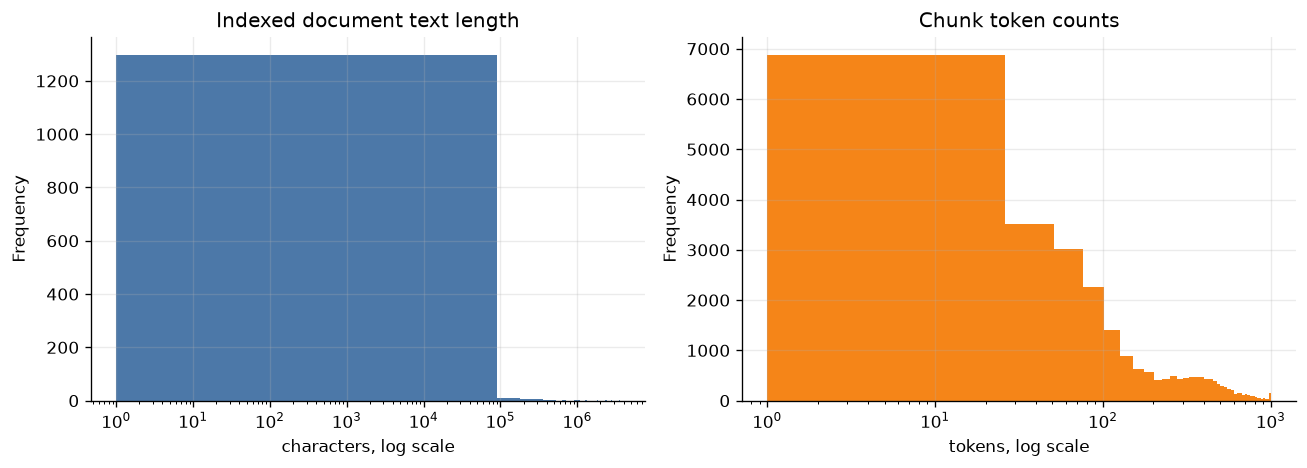

In [20]:
indexed_docs = extraction_docs.loc[extraction_docs["extraction_status"] == "indexed"].copy()
text_lengths = indexed_docs.loc[indexed_docs["text_length"] > 0, "text_length"]
token_counts = chunks.loc[chunks["token_count"].fillna(0) > 0, "token_count"]

if text_lengths.empty and token_counts.empty:
    display_md("_No positive text-length or token-count values to plot._")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    if text_lengths.empty:
        axes[0].text(0.5, 0.5, "No text_length rows", ha="center", va="center")
        axes[0].set_axis_off()
    else:
        text_lengths.plot(kind="hist", bins=40, ax=axes[0], color="#4C78A8")
        axes[0].set_xscale("log")
        axes[0].set_title("Indexed document text length")
        axes[0].set_xlabel("characters, log scale")
    if token_counts.empty:
        axes[1].text(0.5, 0.5, "No token_count rows", ha="center", va="center")
        axes[1].set_axis_off()
    else:
        token_counts.plot(kind="hist", bins=40, ax=axes[1], color="#F58518")
        axes[1].set_xscale("log")
        axes[1].set_title("Chunk token counts")
        axes[1].set_xlabel("tokens, log scale")
    plt.tight_layout()
    plt.show()

In [21]:
failed_extractions = extraction_docs.loc[extraction_docs["extraction_status"] == "failed"].copy()
failed_extractions[
    ["course_name", "relative_path", "extension", "extractor_name", "failure_reason", "extracted_at"]
].head(50)

,course_name,relative_path,extension,extractor_name,failure_reason,extracted_at
25,Structured Programming,Structured Programming\Worksheet-Recursion.doc,.doc,legacy-doc-unsupported,legacy format not supported yet,2026-06-27T16:57:46.729654+00:00
88,Stats for Data Science,Stats for Data Science\Counting Methods and Probability past papers.pdf,.pdf,pdf-pymupdf,"scanned PDF, OCR not available",2026-06-27T16:57:31.216143+00:00
100,Stat Methods,Stat Methods\Testing HypothesesFile.pdf,.pdf,pdf-pymupdf,"scanned PDF, OCR not available",2026-06-27T16:56:10.640120+00:00
102,Stat Methods,Stat Methods\Normal distribution part 2File.pdf,.pdf,pdf-pymupdf,"scanned PDF, OCR not available",2026-06-27T16:56:10.376440+00:00
103,Stat Methods,Stat Methods\Lecture 19( Normal Distribution Part 1)File.pdf,.pdf,pdf-pymupdf,"scanned PDF, OCR not available",2026-06-27T16:56:10.299478+00:00
104,Stat Methods,"Stat Methods\Lecture 18 ( Binomial, Geometric, and Poisson Distributions)File.pdf",.pdf,pdf-pymupdf,"scanned PDF, OCR not available",2026-06-27T16:56:10.207202+00:00
105,Stat Methods,Stat Methods\Lecture 17 ( continuous random variables).pdf,.pdf,pdf-pymupdf,"scanned PDF, OCR not available",2026-06-27T16:56:10.085360+00:00
106,Stat Methods,"Stat Methods\Lecture 16( Discrete Random Variables, pdf, cdf)File.pdf",.pdf,pdf-pymupdf,"scanned PDF, OCR not available",2026-06-27T16:56:09.975167+00:00
107,Stat Methods,Stat Methods\Lecture 15 (Discrete Random Variables)File.pdf,.pdf,pdf-pymupdf,"scanned PDF, OCR not available",2026-06-27T16:56:09.884985+00:00
108,Stat Methods,Stat Methods\Lecture 14 ( Counting Rules Part 2)File.pdf,.pdf,pdf-pymupdf,"scanned PDF, OCR not available",2026-06-27T16:56:09.811496+00:00


## Failure Plots

These views make extractor failures easier to triage before rerunning with OCR, adding a converter, or fixing extractor-specific bugs.

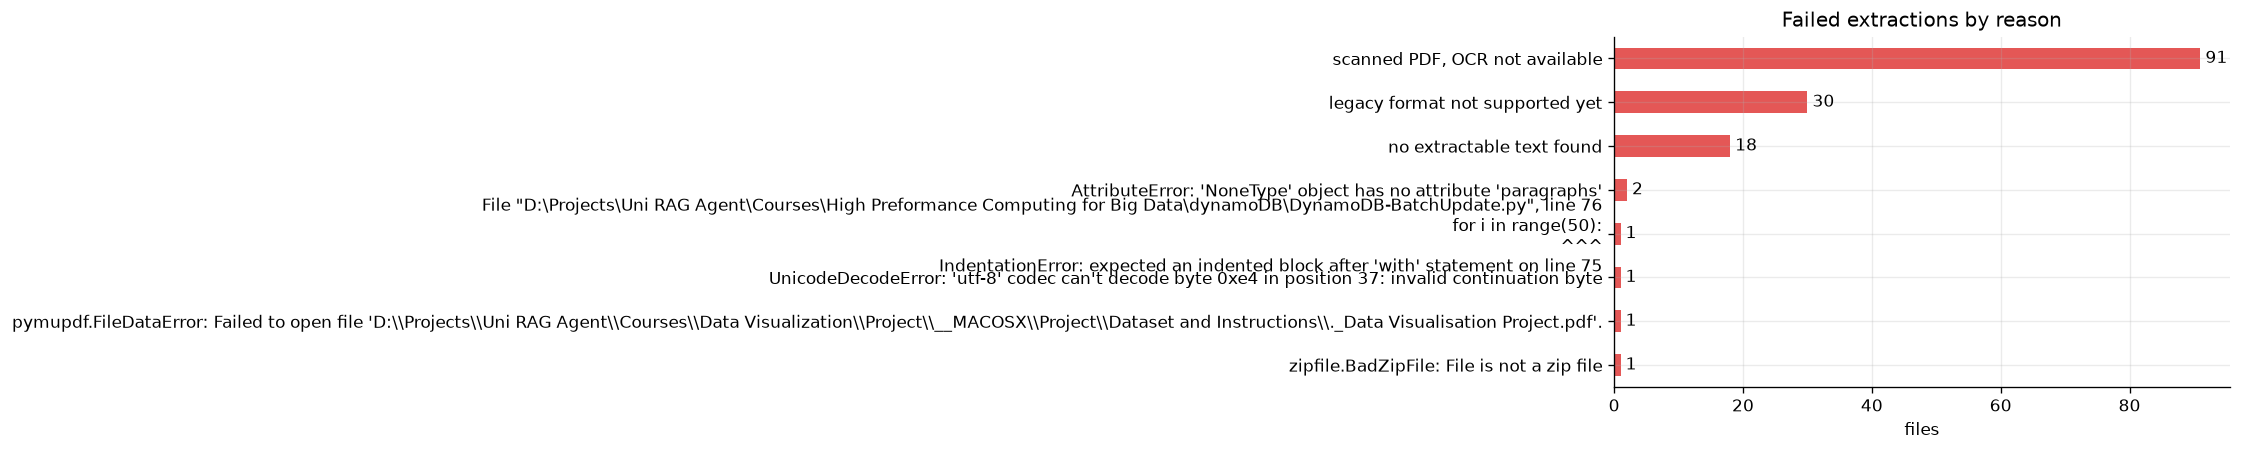

In [22]:
failure_reason_counts = failed_extractions["failure_reason"].fillna("(missing failure reason)").value_counts()
show_barh(
    failure_reason_counts,
    "Failed extractions by reason",
    "files",
    color="#E45756",
)

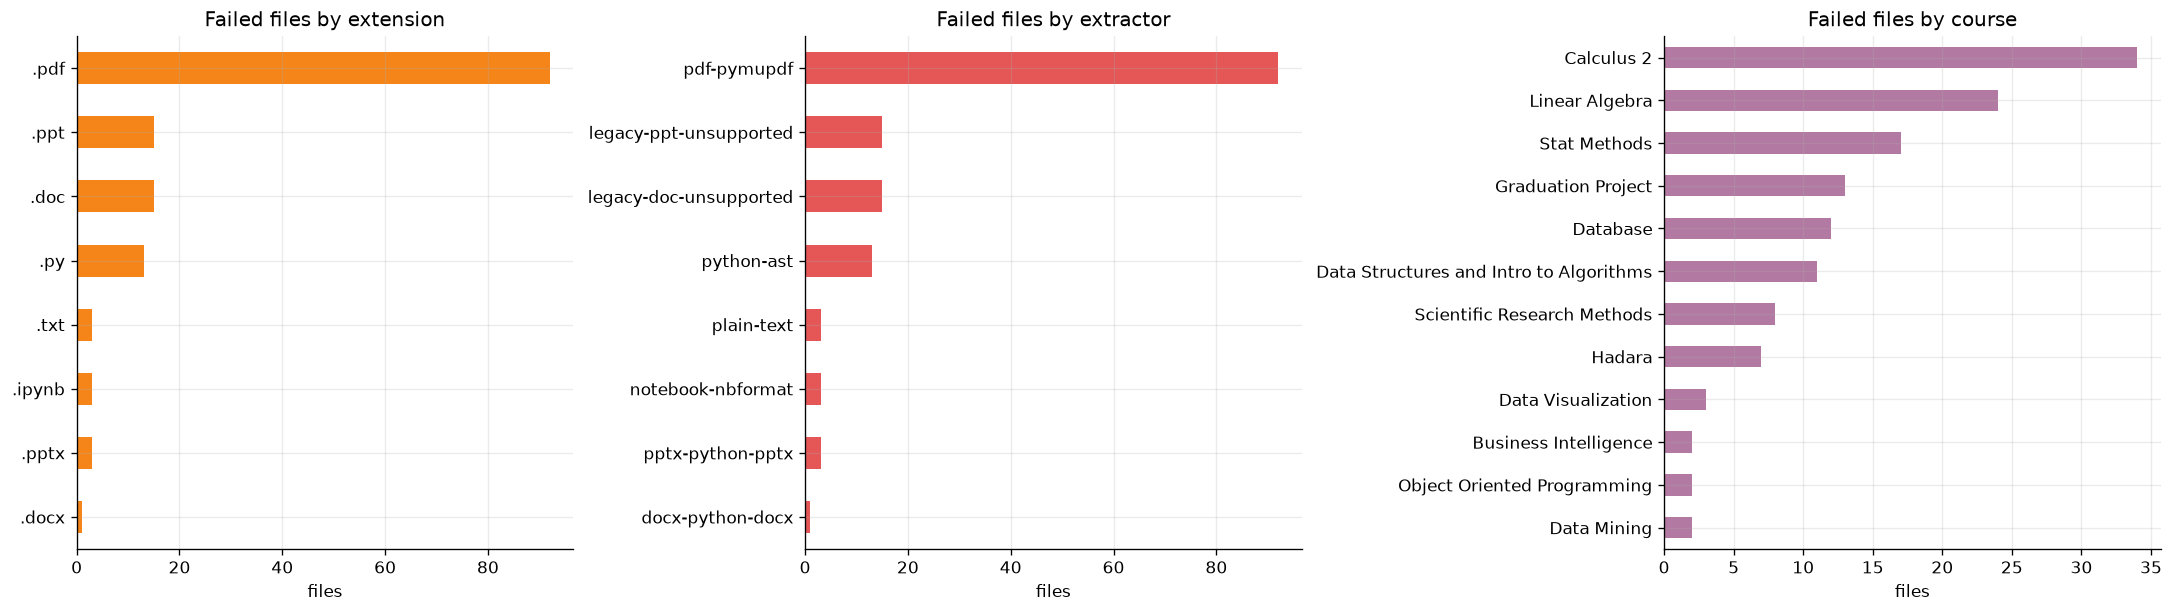

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_specs = [
    (failed_extractions["extension"].fillna("(missing extension)").value_counts().sort_values(ascending=True).tail(12), "Failed files by extension", "#F58518"),
    (failed_extractions["extractor_name"].fillna("(missing extractor)").value_counts().sort_values(ascending=True).tail(12), "Failed files by extractor", "#E45756"),
    (failed_extractions["course_name"].fillna("(missing course)").value_counts().sort_values(ascending=True).tail(12), "Failed files by course", "#B279A2"),
]
for ax, (series, title, color) in zip(axes, plot_specs):
    if series.empty:
        ax.text(0.5, 0.5, "No rows", ha="center", va="center")
        ax.set_axis_off()
        continue
    series.plot(kind="barh", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("files")
    ax.set_ylabel("")
plt.show()